In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('./Churn_Modelling.csv')

data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
X = data.iloc[:, 3:13]
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [5]:
y = data.iloc[:, 13]
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [6]:
pd.get_dummies(X['Geography'], drop_first=True, dtype='int64')

,Germany,Spain
0,0,0
1,0,1
2,0,0
3,0,0
4,0,1
...,...,...
9995,0,0
9996,0,0
9997,0,0
9998,1,0


In [7]:
X = pd.get_dummies(X, dtype='int64')
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,1,0


In [8]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Geography_France   10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Female      10000 non-null  int64  
 12  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(11)
memory usage: 1015.8 KB


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [10]:
# feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [11]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ...,  1.74309049,
         1.09168714, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ..., -0.57369368,
        -0.91601335,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.57369368,
         1.09168714, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.57369368,
        -0.91601335,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ...,  1.74309049,
         1.09168714, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ..., -0.57369368,
         1.09168714, -1.09168714]])

In [12]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ..., -0.57369368,
         1.09168714, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.57369368,
         1.09168714, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ...,  1.74309049,
         1.09168714, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ...,  1.74309049,
        -0.91601335,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ..., -0.57369368,
        -0.91601335,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ..., -0.57369368,
        -0.91601335,  0.91601335]])

In [13]:
print(X_train.shape)
print(X_test.shape)

(8000, 13)
(2000, 13)


In [44]:
# Creating ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

# Sequential() is used to initialize the ANN. It is a linear stack of layers. We can add layers to the model using the add() method.
# Dense() is used to create a fully connected layer. The first argument is the number of neurons in the layer, the second argument is the activation function, and the third argument is the input shape.
# Dropout() is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time, which helps to prevent overfitting.

In [45]:
#Initializing the ANN

classifier = Sequential()

In [46]:
# Adding the input layer and 

classifier.add(Dense(units=13, activation='relu'))

In [47]:
# adding the first hidden layer
classifier.add(Dense(units=6, activation='relu'))
classifier.add(Dropout(0.1))

In [48]:
# adding the second hidden layer
classifier.add(Dense(units=6, activation='relu'))
classifier.add(Dropout(0.3))

In [49]:
# adding the output layer
classifier.add(Dense(units=1, activation='sigmoid'))

In [50]:
# Compiling the ANN
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [51]:
# we can provide our own optimizer to the compile method.
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [52]:
# train our neural network

# model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100)

In [53]:
# early stopping
# early stopping is a form of regularization used to avoid overfitting when training a learner with an iterative method, such as gradient descent. Early stopping rules provide guidance as to how many iterations can be run before the learner begins to over-fit.

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None, 
    restore_best_weights=False
)

In [54]:
# train our neural network with early stopping

model_history = classifier.fit(
    X_train, y_train, validation_split=0.33, batch_size=10, epochs=100, callbacks=[early_stopping]
)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step - accuracy: 0.7645 - loss: 0.5444 - val_accuracy: 0.7997 - val_loss: 0.4515
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - accuracy: 0.8074 - loss: 0.4711 - val_accuracy: 0.8186 - val_loss: 0.4289
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - accuracy: 0.8104 - loss: 0.4476 - val_accuracy: 0.8209 - val_loss: 0.4208
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 943us/step - accuracy: 0.8156 - loss: 0.4378 - val_accuracy: 0.8262 - val_loss: 0.4135
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step - accuracy: 0.8283 - loss: 0.4202 - val_accuracy: 0.8357 - val_loss: 0.3957
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 998us/step - accuracy: 0.8345 - loss: 0.4070 - val_accuracy: 0.8444 - val_loss: 0.3795
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 864us/step - accuracy: 0.8377 - loss: 0.3937 - val_accuracy: 0.8493 - val_loss: 0.3720
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.8410 - loss: 0

In [55]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

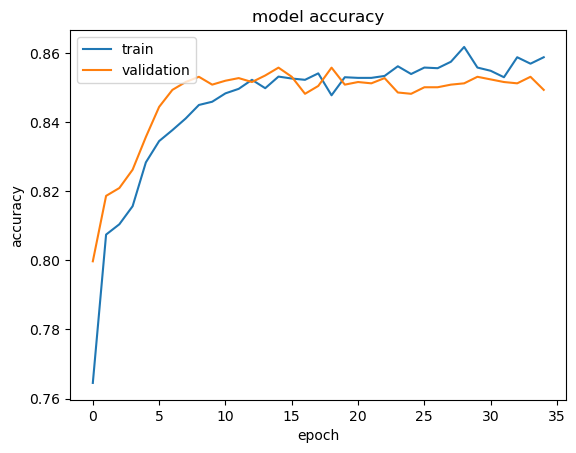

In [56]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

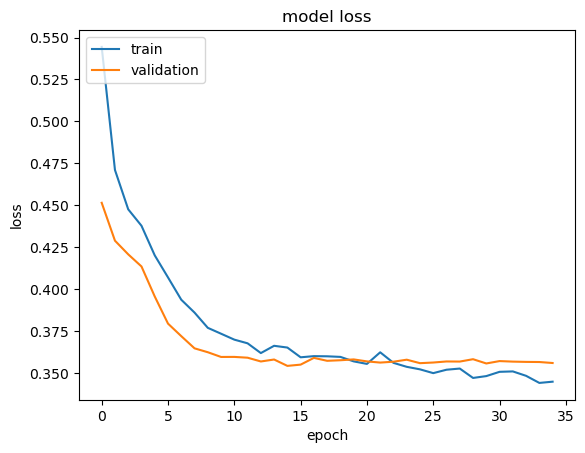

In [57]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [58]:
# Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5) # if the predicted probability is greater than 0.5, we classify it as 1 (churn), otherwise 0 (no churn).

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step


In [59]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1531,   64],
       [ 212,  193]])

In [60]:
# calculating the accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.862

In [61]:
# get the weights 
classifier.get_weights()

[array([[ 0.16773394, -0.07441124,  0.03737489,  0.07680526, -0.06457898,
         -0.10040833,  0.14569335,  0.06063822, -0.17586094, -0.19423833,
         -0.0861321 ,  0.00794128, -0.11359686],
        [ 0.11814593,  0.14112106,  0.60782605, -0.30410573, -0.73757464,
         -0.45562792, -0.40320435, -0.62415874,  0.27354088,  0.8172351 ,
         -0.48632857,  0.25583065,  0.41217077],
        [-0.14118272, -0.04552602, -0.04563373,  0.3910128 ,  0.01575476,
          0.09451029,  0.17697795,  0.12198518, -0.01463081,  0.1333133 ,
         -0.30191344, -0.09284293,  0.07126194],
        [ 0.3628651 ,  0.7931079 , -0.25617802, -0.31866324,  0.23158547,
         -0.22309272, -0.14137639,  0.01211462,  0.6369891 , -0.03730492,
          0.03304788, -0.23069313, -0.47413078],
        [ 0.25019664, -0.06157293, -0.03335964,  0.13315265,  0.25713685,
          0.19933432,  1.0528117 ,  0.27370775,  1.0729237 ,  0.15066448,
          0.2623162 , -0.57680696, -0.74652696],
        [ 0.017

In [66]:
# save the model using the save() method. The model is saved in the HDF5 format, which is a binary data format that can store large amounts of data. The model can be loaded later using the load_model() method.
classifier.save('model.h5')

In [67]:
# save the model using pickle

import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(classifier, file)